# 09 — Produced-water troubleshooting agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/09_produced_water_troubleshooting_agent.ipynb)

Combine water-rate trends, ion compatibility, separation load, and deposit evidence into a ranked troubleshooting package.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** water rates, ion analyses, pH, temperature, pressure,
turbidity, differential pressure, and treatment limits. **Outputs:**
water balance, scale indices, ranked mechanisms, dose screen, and
sampling plan.

A screening saturation index is
$SI=\log_{10}(IAP/K_{sp})$. Positive values flag supersaturation,
but do not replace a validated electrolyte model.

Deep dive: [produced water, sand, and chemicals](../../production/produced_water_sand_chemicals_management.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
wet_feed = dict(NORTHSTAR_GAS)
wet_feed["water"] = 0.12
total = sum(wet_feed.values())
wet_feed = {name: value / total for name, value in wet_feed.items()}
separator = flash_state(wet_feed, 25.0, 55.0)
aqueous_beta = sum(
    phase["beta_mol"]
    for phase in separator["phases"]
    if phase["phase"] == "aqueous"
)
display(pd.DataFrame(separator["phases"]))
print(f"NeqSim aqueous molar fraction={aqueous_beta:.3f}")


NeqSim aqueous molar fraction=0.102


,phase,beta_mol,density_kg_m3
0,gas,0.889780,20.045891
1,oil,0.008181,627.571844
2,aqueous,0.102040,973.217385


In [4]:
wells = pd.DataFrame(
    {
        "well": ["A-1", "A-2", "B-1"],
        "water_m3_d": [1450.0, 980.0, 760.0],
        "barium_mg_l": [170.0, 25.0, 8.0],
        "sulfate_mg_l": [35.0, 920.0, 1100.0],
        "calcium_mg_l": [4200.0, 1900.0, 1600.0],
        "bicarbonate_mg_l": [650.0, 780.0, 720.0],
        "iron_mg_l": [3.5, 1.2, 0.8],
    }
)
weights = wells.water_m3_d / wells.water_m3_d.sum()
mixed = {
    column: float(np.sum(wells[column] * weights))
    for column in wells.columns
    if column.endswith("mg_l")
}

ba_mol_l = mixed["barium_mg_l"] / 1000.0 / 137.327
sulfate_mol_l = mixed["sulfate_mg_l"] / 1000.0 / 96.06
calcium_mol_l = mixed["calcium_mg_l"] / 1000.0 / 40.078
bicarbonate_mol_l = mixed["bicarbonate_mg_l"] / 1000.0 / 61.016
barite_si = math.log10(ba_mol_l * sulfate_mol_l / 1.1e-10)
calcite_si = math.log10(calcium_mol_l * bicarbonate_mol_l / 2.5e-5)
water_utilization = wells.water_m3_d.sum() / 3600.0
inhibitor_mg_l = max(0.0, 8.0 + 5.0 * barite_si)
summary = pd.DataFrame(
    {
        "indicator": ["barite SI", "calcite SI", "water utilization", "dose screen"],
        "value": [barite_si, calcite_si, water_utilization, inhibitor_mg_l],
        "unit": ["log10(IAP/Ksp)", "log10(IAP/Ksp)", "fraction", "mg/L"],
    }
)
display(wells)
display(summary)


,well,water_m3_d,barium_mg_l,sulfate_mg_l,calcium_mg_l,bicarbonate_mg_l,iron_mg_l
0,A-1,1450.0,170.0,35.0,4200.0,650.0,3.5
1,A-2,980.0,25.0,920.0,1900.0,780.0,1.2
2,B-1,760.0,8.0,1100.0,1600.0,720.0,0.8


,indicator,value,unit
0,barite SI,4.525785,log10(IAP/Ksp)
1,calcite SI,1.521377,log10(IAP/Ksp)
2,water utilization,0.886111,fraction
3,dose screen,30.628926,mg/L


In [5]:
day = np.arange(35)
breakthrough = 1.0 / (1.0 + np.exp(-(day - 15.0) / 2.0))
water_rate = 2800.0 + 420.0 * breakthrough + RNG.normal(0.0, 25.0, day.size)
turbidity = 12.0 + 32.0 * breakthrough + RNG.normal(0.0, 1.0, day.size)
filter_dp = 0.35 + 0.55 * breakthrough + RNG.normal(0.0, 0.02, day.size)
hypotheses = pd.DataFrame(
    {
        "mechanism": ["barite scale", "emulsion upset", "corrosion solids", "sand ingress"],
        "score": [
            0.45 * min(barite_si / 5.0, 1.0)
            + 0.30 * min(filter_dp[-1], 1.0)
            + 0.25 * min(turbidity[-1] / 50.0, 1.0),
            0.45 * min(water_utilization, 1.0) + 0.20 * min(turbidity[-1] / 50.0, 1.0),
            0.35 * min(mixed["iron_mg_l"] / 5.0, 1.0) + 0.25 * min(turbidity[-1] / 50.0, 1.0),
            0.25 * min(turbidity[-1] / 50.0, 1.0),
        ],
        "discriminating_sample": [
            "XRD/SEM deposit plus paired Ba/SO4 samples",
            "oil-in-water and bottle test",
            "iron speciation and corrosion coupon",
            "particle-size and mineralogy",
        ],
    }
).sort_values("score", ascending=False)
display(hypotheses)


,mechanism,score,discriminating_sample
0,barite scale,0.890738,XRD/SEM deposit plus paired Ba/SO4 samples
1,emulsion upset,0.573975,oil-in-water and bottle test
2,corrosion solids,0.369542,iron speciation and corrosion coupon
3,sand ingress,0.219032,particle-size and mineralogy


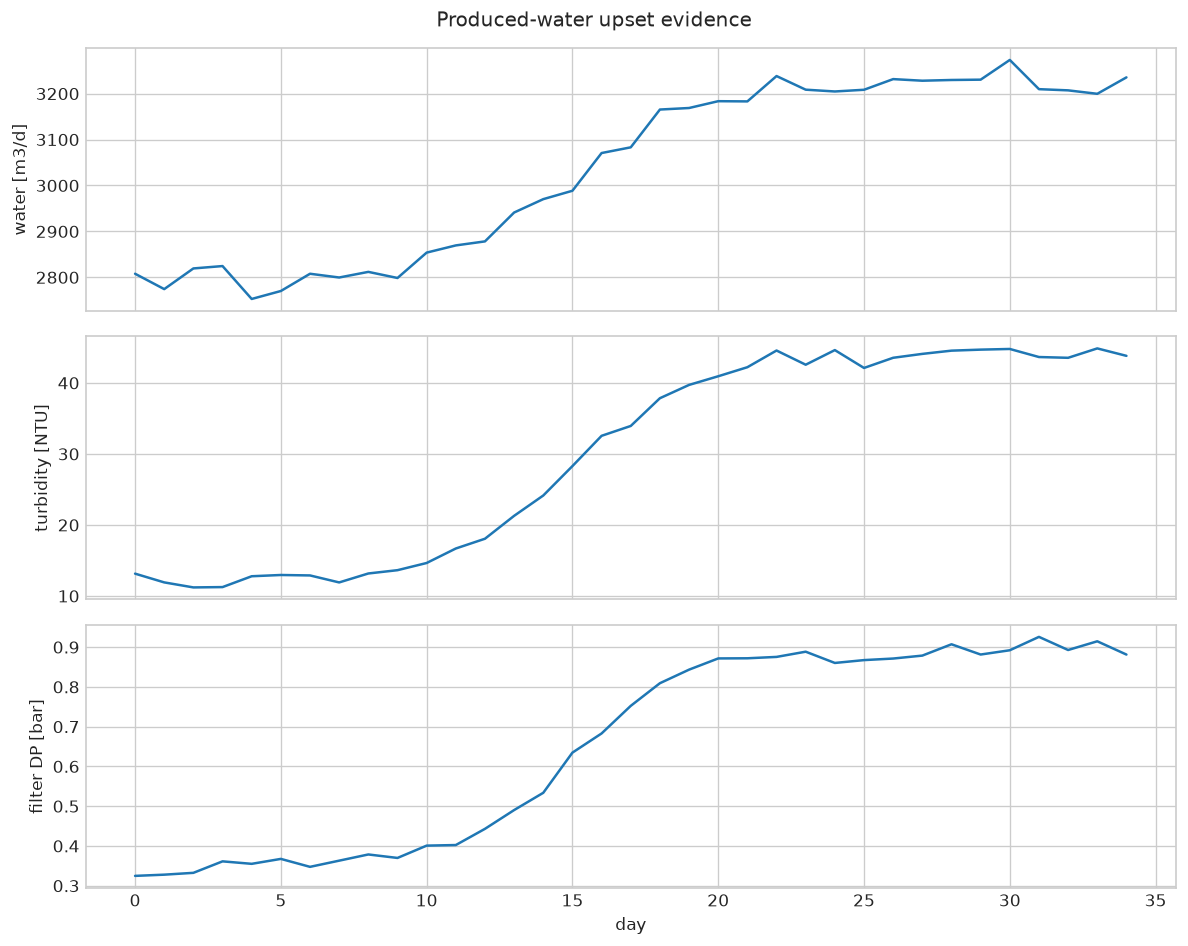

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(day, water_rate)
axes[1].plot(day, turbidity)
axes[2].plot(day, filter_dp)
axes[0].set_ylabel("water [m3/d]")
axes[1].set_ylabel("turbidity [NTU]")
axes[2].set_ylabel("filter DP [bar]")
axes[2].set_xlabel("day")
fig.suptitle("Produced-water upset evidence")
plt.tight_layout()
plt.show()


In [7]:
assert hypotheses.iloc[0].mechanism == "barite scale"
assert barite_si > 1.0
assert water_utilization > 0.80
print("VALIDATION PASSED")
print("Recommendation: confirm deposit mineralogy before changing inhibitor dose.")


VALIDATION PASSED
Recommendation: confirm deposit mineralogy before changing inhibitor dose.


## Interpretation and limits

Commingling creates a strong barite supersaturation screen and the
trend evidence is consistent with deposit buildup. The index omits
activity coefficients, temperature-dependent equilibria, kinetics,
and inhibitor performance; confirm with representative samples and a
qualified electrolyte workflow.
